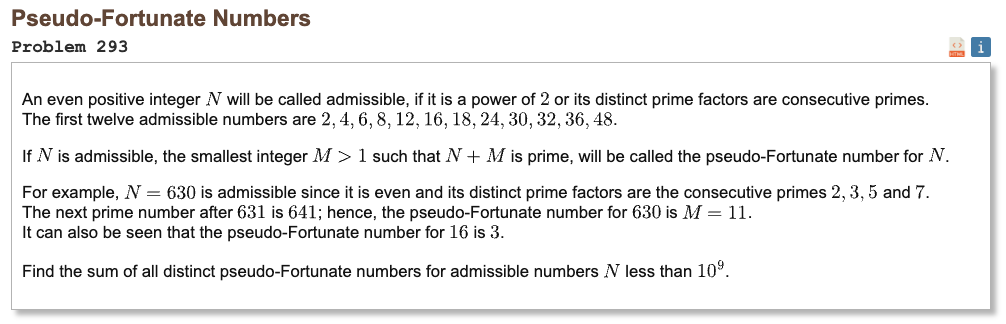

## Initial approach

* first generate all admissible numbers below the limit by multiplying consecutive primes in order, with any positive exponent allowed for each prime
* the rule means once a prime is included, every smaller prime must already be included, so a simple recursive build works well
* there are not that many admissible numbers below one billion, so this generation step is manageable
* for each admissible number, look for the next prime strictly above it, because the wanted offset is just the gap from the number to that next prime
* the offset is never 1 because every admissible number here is even, so start checking from 3 and then only odd offsets
* use a deterministic Miller Rabin primality test for 64 bit integers, which is fast and reliable for these sizes
* collect the offsets in a set so repeated values are counted once
* at the end, add the distinct offsets and print the total

In [1]:
from math import isqrt

def is_prime(n):
    if n < 2:
        return False
    small_primes = (2, 3, 5, 7, 11, 13, 17, 19, 23, 29)
    for p in small_primes:
        if n % p == 0:
            return n == p

    d = n - 1
    s = 0
    while d % 2 == 0:
        s += 1
        d //= 2

    for a in (2, 3, 5, 7, 11):
        if a >= n:
            continue
        x = pow(a, d, n)
        if x == 1 or x == n - 1:
            continue
        witness = True
        for _ in range(s - 1):
            x = (x * x) % n
            if x == n - 1:
                witness = False
                break
        if witness:
            return False
    return True

def generate_admissible(limit):
    primes = []
    candidate = 2
    while candidate <= 50:
        ok = True
        for d in range(2, isqrt(candidate) + 1):
            if candidate % d == 0:
                ok = False
                break
        if ok:
            primes.append(candidate)
        candidate += 1

    values = set()

    def dfs(index, current):
        if current >= limit:
            return
        if current % 2 == 0:
            values.add(current)
        if index >= len(primes):
            return

        p = primes[index]
        nxt = current
        while nxt * p < limit:
            nxt *= p
            dfs(index + 1, nxt)

    dfs(0, 1)
    return values

def solve(limit):
    admissible = generate_admissible(limit)
    pseudo = set()

    for n in admissible:
        m = 3
        while not is_prime(n + m):
            m += 2
        pseudo.add(m)

    return sum(pseudo)

In [2]:
%%time
result = solve(10**9)
print("Result:", result)

Result: 2209
CPU times: user 71.4 ms, sys: 1.67 ms, total: 73.1 ms
Wall time: 72.6 ms
